<a href="https://colab.research.google.com/github/vencov/FAV_course/blob/main/TutCochModels/EX_nobili_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nobili cochlear model


- **Cell 1:** all functions with parameter setting: `gaussgrid`, `interpol`, `psigma`, `mass`, `g0`, `gpeaks`, `greenf`, `bmdata`, `tmdata`, `alldataF`, `alldataRG`, `FreqDomainA`, `KERNCOMB_WMe`, `ItercombPT`, `iso_intrespF`, `CochleaRGB_Nobili`, ...

- **Cell 2:** frequency-domain solution, plots
- **Cell 3:** time-domain solution + optional nonlinear frequency-domain run


In [1]:
import math
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.interpolate import CubicSpline

DATA_DIR = None                  # folder with bmwdata.mat and cddata.mat; None = search automatically
                                 # (if not found, the embedded copy of the data below is used)
HELICOTREMA_FIX = False          # g0.m has a typo (Intp(Nm+1) instead of Intm(Nm+1)); False = reproduce MATLAB exactly

# in-memory replacement of the .mat files written by the MATLAB code
# (bmdata.mat, bmdatarg.mat, tmdata.mat, tm_sp.mat, B_KERNEL.mat)
_MODEL = {}     # keyed by N: dict with BM + TM data
_KERNEL = {}    # kernels of KERNCOMB_WMe


# ============================================================================
#  Basic helpers: gaussgrid, interpol, psigma, db2input, nonlin, Inp_sigSFOAE
# ============================================================================
def gaussgrid(N=500):
    """BM site array (0..1) with Gaussian-distributed spacing."""
    stred, sig1, sig2 = 0.35, 2 * 1.2 ** 2, 2 * 0.46 ** 2
    xo = np.arange(1, N + 1) / N
    ind = int(np.ceil(stred / xo[0]))
    dx = np.empty(N)
    dx[:ind] = np.exp((xo[:ind] - xo[ind - 1]) ** 2 / sig1)
    dx[ind:] = np.exp((xo[ind:] - xo[ind - 1]) ** 2 / sig2)
    x = np.cumsum(dx / dx.sum())
    if x[-1] > 1:
        x[-1] = 1
    return x


def interpol(x, y, X):
    """Spline interpolation with linear extrapolation at the ends (interpol.m)."""
    x = np.asarray(x, float).ravel(); y = np.asarray(y, float).ravel()
    X = np.asarray(X, float).ravel()
    order = np.argsort(x, kind='stable'); x, y = x[order], y[order]
    n = len(x)
    p1 = (y[1] - y[0]) / (x[1] - x[0])
    pn = (y[n - 1] - y[n - 2]) / (x[n - 1] - x[n - 2])
    if x[0] > X[0]:
        y = np.r_[y[0] + p1 * (X[0] - x[0]), y]; x = np.r_[X[0], x]
    if x[-1] < X[-1]:
        y = np.r_[y, y[-1] + pn * (X[-1] - x[-1])]; x = np.r_[x, X[-1]]
    return CubicSpline(x, y, bc_type='not-a-knot')(X)


def psigma(x, b, r):
    """Integrated Green's function peak (psigma.m). Accepts broadcastable arrays."""
    xb, xr = x / b, x / r
    sqb, sqr = np.sqrt(xb ** 2 + 1), np.sqrt(xr ** 2 + 1)
    with np.errstate(divide='ignore', invalid='ignore'):
        return ((xr ** 2 + xb ** 2 + np.log((np.abs(xb) + sqb) / (np.abs(xr) + sqr))) * np.sign(x)
                - xr * sqr - xb * (sqb + np.log((sqb - 1) / (sqb + 1)))) / (2 * np.pi)


def db2input(dB):
    return 1e-6 * 10.0 ** (np.asarray(dB) / 20)


def nonlin(Y):
    """Sigmoidal nonlinearity of the TM feedback."""
    y1, y2, c1, c2, b = 0.01139, 0.03736, 0.7293, 1.4974, 0.30991
    with np.errstate(over='ignore'):
        Z = 1.0 / (1 + c1 * np.exp(-Y / y1) + c2 * np.exp(-Y / y2)) - b
    return 0.1 * Z


def Inp_sigSFOAE(F1, A1, t, phi1):
    """Stapes acceleration: Hann-ramped tone (5 ms ramp), scalar t."""
    om1 = 2 * math.pi * F1
    AM1 = -float(db2input(A1)) * om1 ** 2
    dur = 5e-3
    w = 0.5 * (1 - math.cos(2 * math.pi * t / (2 * dur))) if t <= dur else 1.0
    return w * AM1 * math.cos(om1 * t + phi1)


# --- data of bmwdata.mat / cddata.mat embedded (used if the files are not found) ---
_BMW_EMBED = np.array([0.0, 0.0017991004, 0.0094696969, 0.0024756852, 0.015151515, 0.0028139776, 0.028409091, 0.0033214162, 0.041666666, 0.003558221, 0.05871212, 0.0038288549, 0.083333334, 0.0041107652, 0.22916667, 0.0054921256, 0.32954546, 0.0063860477, 0.38446969, 0.0069580594, 0.43560606, 0.0074936891, 0.57954546, 0.0090723868, 0.68560606, 0.010425557, 0.73863637, 0.011271288, 0.79545454, 0.012398929, 0.83049241, 0.013301042, 0.86553031, 0.014372301, 0.88068183, 0.014710593, 0.89583334, 0.01487974, 0.90909091, 0.014950004, 0.92424243, 0.014936122, 0.94318183, 0.014654211, 0.95833334, 0.014275919, 0.97916666, 0.013413806, 0.98484849, 0.013160087, 0.99431817, 0.012511693, 1.0, 0.012060636]).reshape(27, 2)
_CD_EMBED = [np.array(v) for v in (
    [0.0, 0.0037523446, 0.033771108, 0.043151971, 0.054409007, 0.061913697, 0.068011263, 0.077861159, 0.086303938, 0.12195122, 0.14446529, 0.16135084, 0.1782364, 0.1988743, 0.21575985, 0.24390244, 0.27954973, 0.31519699, 0.33583488, 0.35084427, 0.37335836, 0.38461539, 0.39962477, 0.41651032, 0.42964351, 0.44090057, 0.45590993, 0.47467166, 0.49718572, 0.52532834, 0.54971859, 0.57598501, 0.61913697, 0.70168856, 0.76923078, 0.80675423, 0.84240151, 0.85459662, 0.86679173, 0.89493433, 0.94746717, 0.96622891, 0.97555377, 0.98874297, 1.0],
    [0.03612095051741833, 0.03510325384159839, 0.027914326327793823, 0.02571812778425286, 0.02331597343704399, 0.022525370267236295, 0.022242020986338578, 0.022242020986338578, 0.022525370267236295, 0.024821749089583546, 0.025893679929925487, 0.026344642757723878, 0.02665237683627078, 0.026922967317050756, 0.02695659926020065, 0.026821814901472465, 0.026516047322675384, 0.026584299470184872, 0.027023739934345488, 0.027587832230206655, 0.029798264519191393, 0.030844133593303406, 0.031713153201205095, 0.03211064680973995, 0.031997581363841225, 0.03156997717317611, 0.030400310629379205, 0.028237046679301905, 0.025893679929925487, 0.023701387511162002, 0.022725599846009636, 0.02211947451995114, 0.021705990112585057, 0.021913707507405157, 0.02211947451995114, 0.021913707507405157, 0.02128447433610042, 0.020854440657250728, 0.01996660686877322, 0.018555374402252602, 0.01702757943149277, 0.0162097725454002, 0.015524540183263984, 0.014118523001467686, 0.010427220252308312],
    [0.0, 0.0057915062, 0.0096525092, 0.027027027, 0.038610039, 0.052123552, 0.06949807, 0.08301158, 0.098455595, 0.11080115, 0.12216216, 0.13042471, 0.14092664, 0.16602316, 0.2007722, 0.25482625, 0.3030888, 0.35989382, 0.39587838, 0.43822394, 0.46812742, 0.50125482, 0.51737452, 0.54835907, 0.58687259, 0.61003861, 0.63706564, 0.65462355, 0.67567568, 0.7027027, 0.72200772, 0.76061776, 0.7992278, 0.82432432, 0.84942085, 0.87837838, 0.91505792, 0.95945946, 0.98455599, 1.0],
    [0.04055965547642533, 0.03809916155803332, 0.03706926416828674, 0.034640219544060824, 0.033504164586120294, 0.0326261728810887, 0.032388022339206096, 0.03247753405073751, 0.03321407893635071, 0.03393464195811464, 0.034500258079453304, 0.034556311243401104, 0.03435972742469022, 0.03321407893635071, 0.03141737403762115, 0.028169343516322377, 0.02602668250677085, 0.024015571254165546, 0.02332050505419584, 0.02277467495882514, 0.022646846073385577, 0.022215438085792905, 0.021996561374374817, 0.021417016182470407, 0.02001566218265676, 0.018664701225441244, 0.01759724911397075, 0.01729215155633032, 0.01759724911397075, 0.01917615758078009, 0.020634603681991878, 0.02243217911894785, 0.02277467495882514, 0.02243217911894785, 0.02155214060293586, 0.019821330834874494, 0.01759724911397075, 0.013911846881180648, 0.010776070375314395, 0.007619832395154403],
)]

def _data_dir():
    """Folder containing cddata.mat / bmwdata.mat (searched below the working directory), or None."""
    global DATA_DIR
    if DATA_DIR is not None and (Path(DATA_DIR) / 'cddata.mat').is_file():
        return Path(DATA_DIR)
    cwd = Path.cwd()
    for base in (cwd, *cwd.parents[:2]):               # cwd and two levels up
        if base == Path(base.anchor):                  # never scan the filesystem root
            continue
        for root, dirs, files in os.walk(base, onerror=lambda e: None):
            if 'cddata.mat' in files and 'bmwdata.mat' in files:
                DATA_DIR = root
                print('Using data folder:', DATA_DIR)
                return Path(root)
    return None


def _load_bmw():
    d = _data_dir()
    return np.loadtxt(d / 'bmwdata.mat') if d else _BMW_EMBED.copy()   # [x, BM width]


def _load_cd():
    d = _data_dir()
    if d is None:
        return [v.copy() for v in _CD_EMBED]           # xp, yp, xm, ym
    m = loadmat(d / 'cddata.mat')
    return [m[k].ravel().astype(float) for k in ('xp', 'yp', 'xm', 'ym')]


# ============================================================================
#  Hydrodynamics: mass, g0, gpeaks, greenf
# ============================================================================
def mass(x):
    """Effective organ of Corti mass per unit BM length."""
    x = np.asarray(x, float).ravel()
    bmw = _load_bmw()
    b = interpol(bmw[:, 0], bmw[:, 1], x) / 2
    rho, micron = 0.0376, 29.85e-6
    h = 20 * micron * np.exp(np.log(4) * x)
    m = rho * h * b
    return (m + np.r_[m[0], m[:-1]]) / 2               # local averaging


def g0(x):
    """Coarse Green's functions: G0S (stapes-BM), G0M (BM-BM)."""
    x = np.asarray(x, float).ravel(); N = len(x)
    xp, yp, xm, ym = _load_cd()
    Np, Nm = len(xp) - 1, len(xm) - 1
    Sp = np.pi * ((yp[:Np] + yp[1:]) / 2) ** 2         # circular cross-section areas
    Sm = np.pi * ((ym[:Nm] + ym[1:]) / 2) ** 2
    dxp_S, dxm_S = np.diff(xp) / Sp, np.diff(xm) / Sm

    Intp, Intm = np.zeros(Np + 1), np.zeros(Nm + 1)
    Intp[Np] = 0.5 * np.pi * yp[Np] / Sp[Np - 1]        # helicotrema, upper side
    if HELICOTREMA_FIX:
        Intm[Nm] = 0.5 * np.pi * ym[Nm] / Sm[Nm - 1]
    # (MATLAB writes this term to Intp(Nm+1) which is overwritten by the loop below)
    for i in range(Np - 1, -1, -1):
        Intp[i] = Intp[i + 1] + dxp_S[i]
    for i in range(Nm - 1, -1, -1):
        Intm[i] = Intm[i + 1] + dxm_S[i]

    G0S = interpol(xp, Intp, x) + interpol(xm, Intm, x)
    G0M = np.tile(G0S[:, None], (1, N))
    G0M = np.tril(G0M) + np.tril(G0M).T - np.diag(G0S)
    return G0S, G0M


def gpeaks(x):
    """Peak matrix P (with image peak mirrored at the stapes) and dx."""
    x = np.asarray(x, float).ravel(); N = len(x)
    c = np.r_[x[0], x[1:] + x[:-1]] / 2                 # NB: /2 applies to c[0] as well (as in MATLAB)
    bmw = _load_bmw()
    b = interpol(bmw[:, 0], bmw[:, 1], x) / 2
    xp, yp, xm, ym = _load_cd()
    r = (interpol(xp, yp, c) + interpol(xm, ym, c)) / 2
    xo = np.r_[0.0, x[:-1]]
    dx = x - xo
    X, XO = x[:, None], xo[:, None]
    cj, bj, rj = c[None, :], b[None, :], r[None, :]
    P = (psigma(X - cj, bj, rj) - psigma(XO - cj, bj, rj)
         + psigma(X + cj, bj, rj) - psigma(XO + cj, bj, rj))
    return P, dx


def greenf(x):
    """Returns Gs (stapes->BM), G (BM->BM), Sh (shear operator), b (BM width)."""
    x = np.asarray(x, float).ravel()
    rho = 0.0376                                        # water density [kg/BETA^3]
    Gs, G = g0(x)
    bmw = _load_bmw()
    b = interpol(bmw[:, 0], bmw[:, 1], x) / 2
    P, dx = gpeaks(x)
    G = G * dx[None, :] + 0.5 * P
    G = G * (rho * np.outer(b, b))
    S = 3.2 / 33.5 ** 2 / 2                             # effective stapes area
    Gs = rho * S * b * Gs

    invdx = 1 / dx
    Der = np.diag(invdx)
    Derr = Der - np.diag(invdx[1:], -1)
    Derl = Der - np.diag(invdx[:-1], 1)
    micron = 29.85e-6
    h = 20 * micron * np.exp(np.log(4) * x)
    w = 50 * micron * np.exp(np.log(4) * x)
    s = (1e-3 / 29.85) * w * h                          # sectional shear viscosity
    Sh = Derl @ np.diag(s) @ Derr
    return Gs, G, Sh, b


# ============================================================================
#  Model data: bmdata (= bmdatarg), tmdata, alldataF, alldataRG
# ============================================================================
def bmdata(N=300):
    x = gaussgrid(N)
    Gs, G, Sh, Wb = greenf(x)
    M = np.diag(mass(x))
    dx = np.r_[x[0], np.diff(x)]
    expk, ko = -3.6 * np.log(10), 2e3
    k1 = ko * np.exp(expk * x)
    stiff = np.r_[k1[0] - ko, np.diff(k1)] / (expk * dx)
    ho = 10e-3
    dampn = ho * np.exp(-np.log(4) * x)
    hbo, heo = 1.1 * ho, 1.3 * dampn[-1]
    damp0 = hbo * np.exp(np.log(heo / hbo) * x)
    dampn = dampn + 2 * dampn[-1] * np.exp((x - 1) / 0.075)
    ShSp = np.diag(dampn) + 65 * Sh
    Ginv = np.linalg.inv(G + M)                         # time-domain quantities
    return dict(x=x, N=N, M=M, stiff=stiff, dampn=dampn, damp0=damp0, ShSp=ShSp, G=G, Gs=Gs,
                Ginv=Ginv, BMinput=Ginv @ Gs, Wb=Wb, Qbm=G[0, :], Qs=Gs[0])


bmdatarg = bmdata                                       # identical, Qbm/Qs are always included


def tmdata(N=600):
    x = gaussgrid(N)
    base, alpha, Fo, x0 = 2.4531, -6.36, 2.11e4, 0.05
    wm = 2 * np.pi * Fo * base ** (alpha * (x + x0))
    bigamma = 2 * np.pi * Fo * base ** (0.5 * alpha * (x + x0)) / 0.95
    return dict(bigamma=bigamma, wm2=wm * wm)


def _get_model(N, rebuild_flag):
    if rebuild_flag == 1 or N not in _MODEL:
        _MODEL[N] = dict(bm=bmdata(N), tm=tmdata(N))
    return _MODEL[N]['bm'], _MODEL[N]['tm']


def alldataF(N=800, rebuild_flag=0, gain=0.85):
    bm, tm = _get_model(N, rebuild_flag)
    undamp = gain * bm['damp0'] * tm['bigamma']
    return (bm['x'], bm['Gs'], bm['G'], bm['M'], bm['stiff'], bm['ShSp'], undamp,
            tm['bigamma'], tm['wm2'], bm['Wb'])


def alldataRG(N=800, rebuild_flag=0, gain=0.87):
    bm, tm = _get_model(N, rebuild_flag)
    undamp = gain * bm['damp0'] * tm['bigamma']
    return (bm['x'], bm['BMinput'], bm['Ginv'], bm['stiff'], bm['ShSp'], undamp,
            tm['bigamma'], tm['wm2'], bm['Qbm'], bm['Qs'])


# ============================================================================
#  Frequency-domain solver (FreqDomainA.m)
# ============================================================================
def FreqDomainA(F=2000, Inp=10, plotflag=1, gain=0.94, rebuild_flag=1):
    """Nobili model BM response to a pure tone in the frequency domain.
    Returns Y (active BM displacement) and Yp (passive BM displacement)."""
    N = 800
    x, Gs, G, M, stiff, DampSp, undamp, bigamma, wm2, Wb = alldataF(N, rebuild_flag, gain)

    AM = db2input(Inp)
    Gs = AM * Gs
    omega = 2 * np.pi * F; omega_2 = omega * omega
    Bh = DampSp / omega
    Bk = np.diag(stiff / omega_2)
    Th = 1j * omega * bigamma
    TM = np.diag(undamp / (omega_2 - Th - wm2))         # second array of oscillators (TM)

    A = G + M - 1j * Bh - Bk + TM                       # active model
    Ap = G + M - 1j * Bh - Bk                           # passive model
    Y = -np.linalg.solve(A, Gs.astype(complex))
    Yp = -np.linalg.solve(Ap, Gs.astype(complex))

    # ---- place for your code which returns pressure / impedance along the BM ----

    if plotflag == 1:
        Ya, Yph = np.abs(Y), np.unwrap(np.angle(Y)) / np.pi
        tm = np.diag(TM)
        TMa, TMph = np.abs(tm), np.unwrap(np.angle(tm)) / np.pi
        Ypa, Ypph = np.abs(Yp), np.unwrap(np.angle(Yp)) / np.pi
        idx = np.where(TMph * np.pi < np.pi / 2)[0]
        xAmp = x[idx[0]] if idx.size else None          # TM phase reaches pi/2

        fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 8), num=1, clear=True)
        a1.plot(x, Ya / Ya.max(), 'r', x, TMa / TMa.max(), 'b', x, Ypa / Ypa.max(), 'k')
        if xAmp is not None: a1.axvline(xAmp, color='k', lw=1.6)
        a1.set_ylim(0, 1.1); a1.grid(True)
        a1.legend(['BM displacement-active', 'TM feedback', 'BM displacement-passive'])
        a1.set_ylabel('Amplitude')
        a1.set_title(f'Input-> frequency: {F} [Hz]; amplitude: {Inp} [dB]')
        a2.plot(x, Yph, 'r', x, TMph, 'b', x, Ypph, 'k')
        if xAmp is not None: a2.axvline(xAmp, color='k', lw=1.6)
        a2.set_ylim(-10, 1); a2.grid(True)
        a2.set_xlabel('Distance from stapes [cm]'); a2.set_ylabel('Phase[$\\pi$]')
        fig.tight_layout()

        TMY = tm * Y
        fig, (b1, b2) = plt.subplots(2, 1, figsize=(8, 8), num=2, clear=True)
        b1.plot(x, Yph, 'r', x, np.unwrap(np.angle(TMY)) / np.pi)
        if xAmp is not None: b1.axvline(xAmp, color='k', lw=1.6)
        b1.set_ylim(-10, 1); b1.grid(True)
        b1.legend(['BM phase-active', 'Undamping force phase']); b1.set_ylabel('Phase ($\\pi$)')
        b1.set_title(f'Input-> frequency: {F} [Hz]; amplitude: {Inp} [dB]')
        b2.plot(x, np.unwrap(np.angle(TMY) - Yph * np.pi) / np.pi, 'k')
        if xAmp is not None: b2.axvline(xAmp, color='k', lw=1.6)
        b2.set_ylim(0, 1); b2.grid(True)
        b2.set_xlabel('Distance from stapes (cm)')
        b2.set_ylabel('$\\Delta$ Phase Undamping f. - BM disp($\\pi$)')
        fig.tight_layout()
    return Y, Yp


# ============================================================================
#  Nonlinear frequency-domain solver (KERNCOMB_WMe.m, ItercombPT.m, iso_intrespF.m)
# ============================================================================
def KERNCOMB_WMe(Hz, N=600, rebuild_flag=0, gain=0.85):
    """Kernels KB = inv(G+M-K/w^2-i*D/w) for the frequencies Hz (kept in memory)."""
    x, Gs, G, M, stiff, ShSp, undamp, bigamma, wm2, _ = alldataF(N, rebuild_flag, gain)
    Hz = np.atleast_1d(Hz)
    KB = np.zeros((len(Hz), N, N), dtype=complex)       # KB[j] == KB(:,:,j)
    UB = np.zeros((N, len(Hz)))
    for j, f in enumerate(Hz):
        om = 2 * np.pi * f; om2 = om ** 2
        KB[j] = np.linalg.inv(G + M - np.diag(stiff / om2) - 1j * ShSp / om)
        UB[:, j] = undamp / om2
    _KERNEL.update(wm2=wm2, bigamma=bigamma, Gs=Gs, X0=x, KB=KB, UB=UB, Hz=Hz.copy())


def ItercombPT(Inp=10, rebuildflag=1, Hz=4600, Nit=150, plotflag=1, TW0=None, gain=0.9):
    """Iterative solution of the nonlinear BM-TM equation (harmonic balance).
    TW0: N x L initial guess, L = number of harmonics. Returns TW, NL (both N x L)."""
    N, T = 800, 10
    if TW0 is None or np.size(TW0) == 0:
        TW0 = np.zeros((N, 1), dtype=complex)
    TW0 = np.asarray(TW0, dtype=complex)
    L = TW0.shape[1]
    W = np.arange(1, L + 1)
    TW = np.zeros((N, L), dtype=complex)
    NL = TW0.copy()
    stimul = np.zeros(L); stimul[0] = db2input(Inp)

    E = np.exp(2j * np.pi / (L * T) * np.outer(W, np.arange(L * T)))     # DFT matrix, L x LT

    # kernels: recompute if requested (or if stored kernels belong to another frequency)
    if (rebuildflag == 1 or 'KB' not in _KERNEL
            or not np.allclose(_KERNEL['Hz'], Hz * W)):
        KERNCOMB_WMe(Hz * W, N, rebuildflag, gain)

    omega = 2 * np.pi * Hz * W
    omega_2 = omega ** 2
    wm2, bigamma, Gs, X0 = _KERNEL['wm2'], _KERNEL['bigamma'], _KERNEL['Gs'], _KERNEL['X0']
    KB, UB = _KERNEL['KB'], _KERNEL['UB']
    beta_iom = omega_2[None, :] / (-omega_2[None, :] + 1j * omega[None, :] * bigamma[:, None]
                                   + wm2[:, None])                        # N x L (TM transfer function)

    for cycle in range(1, Nit + 1):
        if cycle > 1:
            NLr = np.real((TW * beta_iom) @ E)          # inverse DFT
            NL = (nonlin(NLr) @ E.conj().T) / (L * T / 2)   # nonlinearity -> DFT
        for j in range(L):
            TW[:, j] = KB[j] @ (UB[:, j] * NL[:, j] - stimul[j] * Gs)

    if plotflag == 1:
        Y1 = FreqDomainA(Hz, 10, 0)[0]
        fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 6))
        a1.plot(X0, np.abs(TW[:, 0]), 'r', X0, np.abs(Y1), 'b')
        a2.plot(X0, np.unwrap(np.angle(TW[:, 0])) / np.pi, 'r', X0, np.unwrap(np.angle(Y1)) / np.pi, 'b')
    return TW, NL


def iso_intrespF(F, L=60, Nharm=3, gain=0.9, Nit=150):
    """Iso-intensity response: BM displacement at the best-frequency place vs. tone frequency.
    (Reconstruction of the unfinished script iso_intrespF.m: Nharm is my assumption.)"""
    F = np.atleast_1d(F); N = 800
    YT = np.zeros((N, Nharm, len(F)), dtype=complex)
    NLs = np.zeros((N, Nharm, len(F)), dtype=complex)
    ExcF = np.zeros(len(F))
    rebuildflag = 1
    for k, f in enumerate(F):
        TW0 = np.zeros((N, Nharm), dtype=complex)
        TW0[:, 0] = FreqDomainA(f, L, 0, gain, rebuildflag)[0]
        if k == 0:
            idxCh = np.argmax(np.abs(TW0[:, 0]))        # BF place at the first frequency
        rebuildflag = 0 if k > 0 else 1
        YT[:, :, k], NLs[:, :, k] = ItercombPT(L, rebuildflag, f, Nit, 0, TW0, gain)
        ExcF[k] = np.abs(YT[idxCh, 0, k])
        rebuildflag = 0
    return ExcF, YT, NLs, idxCh


# ============================================================================
#  Time-domain solver (CochleaRGB_Nobili.m), Dormand-Prince Runge-Kutta, fixed step
# ============================================================================
def CochleaRGB_Nobili(A1o=50, F1o=2700, Tdur=0.1, Ma=2e-2, gain=0.85, phi1o=0, plotflag=0, snap_every=0):
    """Time-domain Nobili model. Returns Y1FT (BM displacement DFT), oae (stapes pressure), tim,
    snaps (dict with BM displacement snapshots every `snap_every` steps, for the animation; empty if 0).
    Ma (animation y-scaling) is only used by the caller."""
    A1, F1, phi1 = A1o, F1o, phi1o
    h = 5e-6; fs = 1 / h
    im1 = -2j * np.pi * F1
    N = 800
    x, BMinput, Ginv, stiff, DampSp, undamp, bigamma, wm2, Qbm, Qs = alldataRG(N, 1, gain)

    Lp = int(Tdur * fs)
    ts = 80 * (1 / F1)                                  # 80 periods before the DFT window
    NuSa = Lp - int(ts * fs)

    def activeC(t, y):
        inp = Inp_sigSFOAE(F1, A1, t, phi1)
        X, V, Y = y[:N], y[N:2 * N], y[2 * N:3 * N]
        Wv = y[3 * N:]
        dV = -BMinput * inp - Ginv @ (stiff * X + DampSp @ V + undamp * nonlin(Y))
        return np.concatenate([V, dV, Wv, -bigamma * Wv - wm2 * Y - dV])

    A = np.array([1/5, 3/10, 4/5, 8/9, 1, 1])
    B = np.array([
        [1/5, 3/40, 44/45, 19372/6561, 9017/3168, 35/384],
        [0, 9/40, -56/15, -25360/2187, -355/33, 0],
        [0, 0, 32/9, 64448/6561, 46732/5247, 500/1113],
        [0, 0, 0, -212/729, 49/176, 125/192],
        [0, 0, 0, 0, -5103/18656, -2187/6784],
        [0, 0, 0, 0, 0, 11/84]])
    hA, hB = h * A, h * B

    y = np.zeros(4 * N); t = 0.0
    Fk = np.zeros((4 * N, 6))
    Y1FT = np.zeros(N, dtype=complex)
    oae = np.zeros(Lp); tim = np.zeros(Lp)
    snap_t, snap_y = [], []

    for count in range(Lp):
        Fk[:, 0] = activeC(t, y)
        for s in range(1, 6):
            Fk[:, s] = activeC(t + hA[s - 1], y + Fk @ hB[:, s - 1])
        II = Inp_sigSFOAE(F1, A1, t + hA[5], phi1)
        dy = Fk @ hB[:, 5]
        oae[count] = Qs * II + Qbm @ dy[N:2 * N] / h
        t = t + hA[5]
        tim[count] = t
        y = y + dy
        if snap_every and count % snap_every == 0:
            snap_t.append(t); snap_y.append(y[:N].copy())     # BM displacement snapshot
        if t > ts:
            Y1FT += y[:N] * np.exp(im1 * t)
    Y1FT = 2 * Y1FT / NuSa

    if plotflag:
        fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 6))
        a1.plot(x, np.abs(Y1FT)); a1.set_ylabel('|BM displacement|'); a1.set_xlabel('Distance from stapes')
        a2.plot(tim, oae); a2.set_xlabel('Time [s]'); a2.set_ylabel('Stapes pressure (OAE)')
        fig.tight_layout()
    snaps = dict(t=np.array(snap_t), y=np.array(snap_y))
    return Y1FT, oae, tim, snaps

### 1. Solution in the frequency domain, linear model!

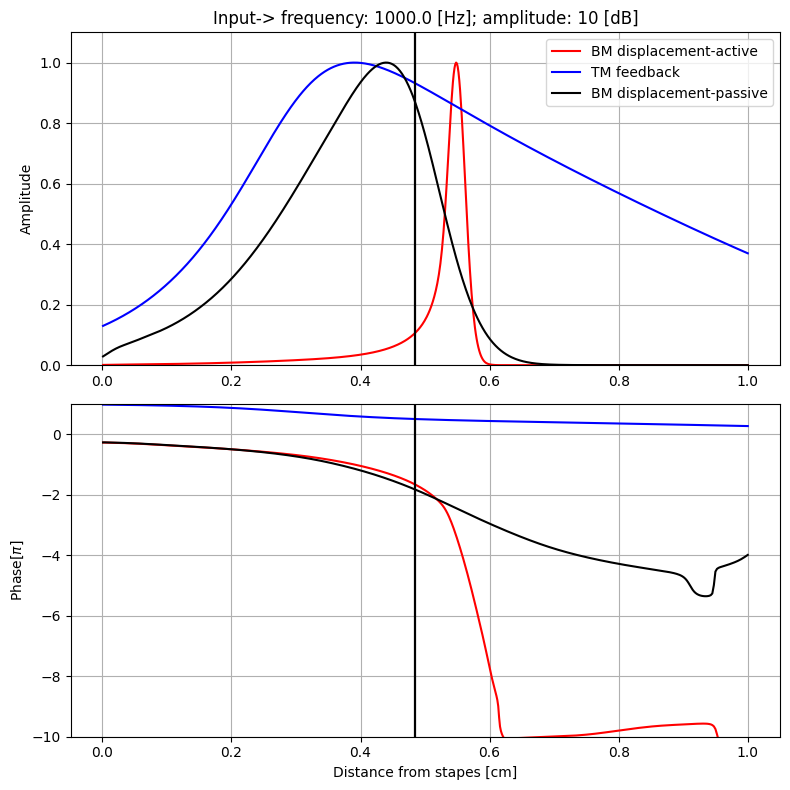

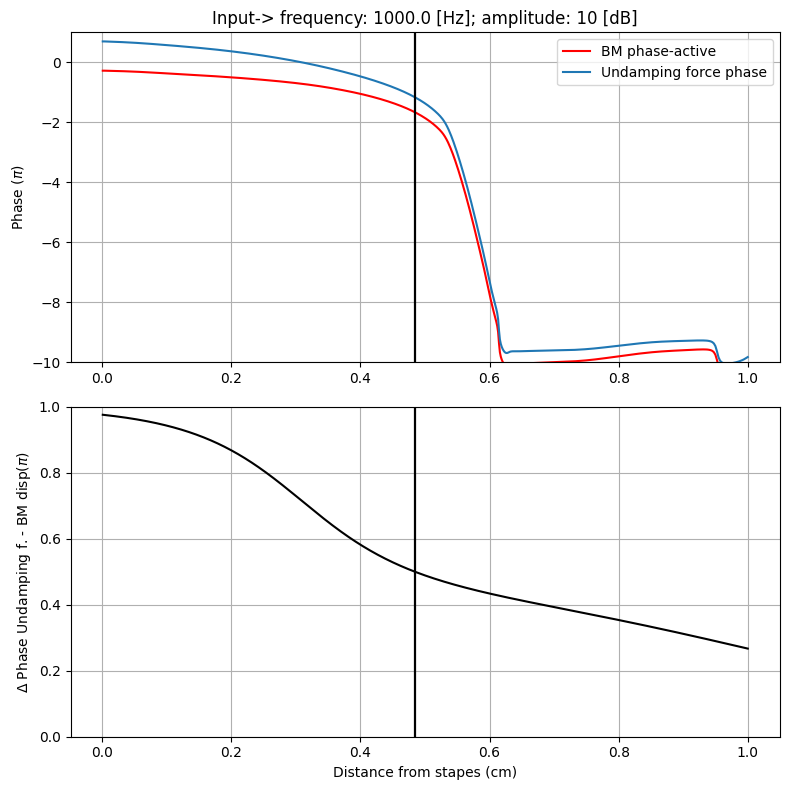

In [2]:
# ===== run_nobiliFD.m: Nobili model in the frequency domain =====
# The model is linear unless gain != 0 (then the TM feedback makes it active).
# Extension task from the original script: calculate the impedance along the BM
# and find the region of negative real impedance (where the traveling wave is amplified).
# -> add your code at the marked place inside FreqDomainA.

Ftone = 1e3      # frequency of the tone [Hz]
Lspl = 10        # level of the tone [dB] (model is linear, so it only scales the output)
gain = 0.9       # model gain
plotflag = 1     # 1 - plot figures

Y, Yp = FreqDomainA(Ftone, Lspl, plotflag, gain)   # Y: active BM disp., Yp: passive BM disp.
plt.show()

## Pressure and impedance along the BM (frequency domain)

This cell extends the frequency-domain solution (`FreqDomainA`) and shows **where the model amplifies**.

**How it is calculated** (time dependence `exp(+iωt)`, BM velocity `v = iωY`)
1. The fluid pressure acting on the BM follows from the hydrodynamic Green's functions:
   `p = -(G·acc_BM + Gs·acc_stapes) = ω² (G·Y + Gs·AM)`.
2. The BM impedance is `Z = p / v`. For the passive model `Z = iωM + D + K/(iω)`, so `Re(Z) = D > 0` (energy is dissipated).
3. The undamping force of the TM feedback adds a term `iω·TM` whose real part is negative. Where it outweighs the damping,
   `Re(Z) < 0` (**negative resistance**): the BM delivers energy to the traveling wave instead of taking it, which is the
   cochlear amplifier. Equivalently, the local power `½ Re(p·v*) = ½ |v|² Re(Z)` is negative.

**What you get** (one column per tone frequency in `Ftones`): normalized BM displacement, pressure amplitude, `Re(Z)` and `Im(Z)`
(symlog axes, active vs. passive model). The orange regions mark where `Re(Z) < 0`; the dash-dotted line marks the displacement peak.
The pressure is also recomputed from the organ-of-Corti side as a consistency check (relative difference ~1e-13).

**Notes**
- Values are per BM section in model units; a positive scaling does not change the sign of `Re(Z)`.
- The model is linear here, so the level only scales `p` and `Y`; `Z` does not depend on it. Set `gain = 0` to see that `Re(Z) > 0` everywhere.
- Very short negative blips and tails where the response is negligible (e.g. 0.62-0.67 at 1 kHz) carry almost no power.

1 kHz: Re(Z) < 0 for x = 0.41-0.54, 0.62-0.67  (BM displacement peak at x = 0.548); passive model Re(Z) < 0 anywhere: False; pressure consistency check: 1.6e-13
3 kHz: Re(Z) < 0 for x = 0.25-0.34  (BM displacement peak at x = 0.347); passive model Re(Z) < 0 anywhere: False; pressure consistency check: 3.1e-13


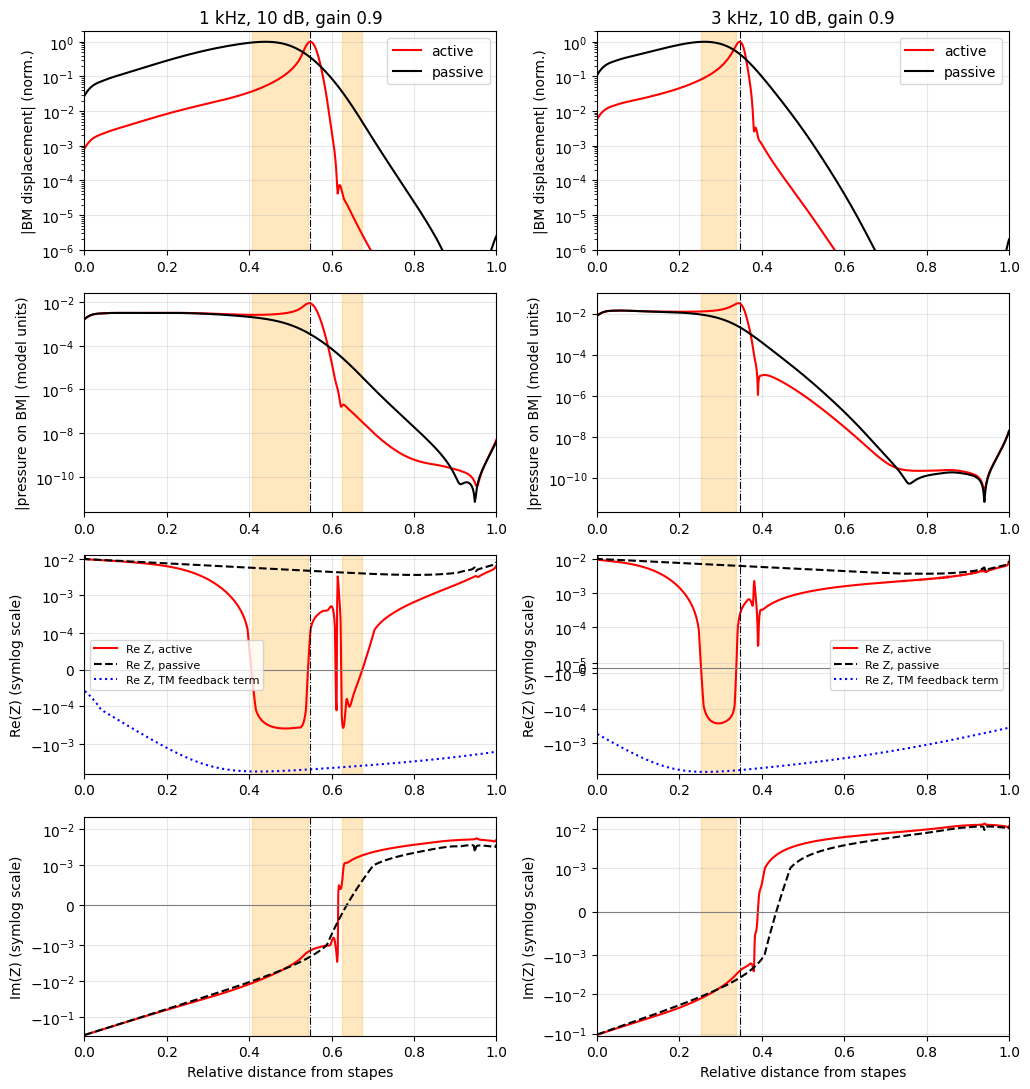

In [ ]:
# ===== Pressure and impedance along the BM (frequency domain) =====
Ftones = [1e3, 3e3]      # tone frequencies in Hz (one column of plots each)
Lspl = 10                # level in dB (the model is linear, so it only scales pressure and displacement)
gain = 0.9               # gain of the cochlear amplifier; gain = 0 gives the passive model


def bm_pressure_impedance(F, Inp=10, gain=0.9, N=800):
    """Pressure p on the BM and BM impedance Z = p / v (v = i*omega*Y, time dependence exp(+i*omega*t)).
    Values are per BM section in model units (positive scaling does not change the sign of Re Z)."""
    x, Gs, G, M, stiff, DampSp, undamp, bigamma, wm2, _ = alldataF(N, 0, gain)
    Y, Yp = FreqDomainA(F, Inp, 0, gain, 0)               # active / passive BM displacement
    om = 2 * np.pi * F
    Gs_in = db2input(Inp) * Gs                             # stapes term scaled by the stimulus

    # fluid pressure acting on the BM: p = -(G*acc_BM + Gs*acc_stapes), acceleration = -omega^2 * displacement
    p = om ** 2 * (G @ Y + Gs_in)
    pp = om ** 2 * (G @ Yp + Gs_in)                        # passive model
    Z = p / (1j * om * Y)
    Zp = pp / (1j * om * Yp)

    # the same pressure from the organ-of-Corti side (mass + damping + stiffness + TM feedback): consistency check
    tm = undamp / (om ** 2 - 1j * om * bigamma - wm2)      # TM transfer function
    p_mech = -om ** 2 * (M @ Y) + 1j * om * (DampSp @ Y) + stiff * Y - om ** 2 * tm * Y
    err = np.abs(p - p_mech).max() / np.abs(p).max()
    Z_tm = 1j * om * tm                                    # impedance of the TM (undamping) feedback term alone
    return dict(F=F, x=x, Y=Y, Yp=Yp, p=p, pp=pp, Z=Z, Zp=Zp, Z_tm=Z_tm, err=err)


def neg_segments(x, re_z, min_pts=5):
    """Contiguous regions where Re(Z) < 0 (ignoring very short blips)."""
    d = np.diff(np.r_[0, (re_z < 0).astype(int), 0])
    st, en = np.where(d == 1)[0], np.where(d == -1)[0] - 1
    return [(x[a], x[b]) for a, b in zip(st, en) if b - a + 1 >= min_pts]


imp = [bm_pressure_impedance(F, Lspl, gain) for F in Ftones]

nC = len(imp)
fig, axs = plt.subplots(4, nC, figsize=(5.2 * nC, 11), squeeze=False, num=4, clear=True)
for c, r in enumerate(imp):
    x = r['x']
    segs = neg_segments(x, np.real(r['Z']))
    xpk = x[np.argmax(np.abs(r['Y']))]
    txt = ', '.join(f'{a:.2f}-{b:.2f}' for a, b in segs) or 'none'
    print(f"{r['F']/1e3:g} kHz: Re(Z) < 0 for x = {txt}  (BM displacement peak at x = {xpk:.3f}); "
          f"passive model Re(Z) < 0 anywhere: {bool((np.real(r['Zp']) < 0).any())}; "
          f"pressure consistency check: {r['err']:.1e}")

    a0, a1, a2, a3 = axs[:, c]
    a0.semilogy(x, np.abs(r['Y']) / np.abs(r['Y']).max(), 'r', label='active')
    a0.semilogy(x, np.abs(r['Yp']) / np.abs(r['Yp']).max(), 'k', label='passive')
    a0.set_ylim(1e-6, 2); a0.set_ylabel('|BM displacement| (norm.)'); a0.legend()
    a0.set_title(f"{r['F']/1e3:g} kHz, {Lspl:g} dB, gain {gain:g}")

    a1.semilogy(x, np.abs(r['p']), 'r', x, np.abs(r['pp']), 'k')
    a1.set_ylabel('|pressure on BM| (model units)')

    a2.plot(x, np.real(r['Z']), 'r', label='Re Z, active')
    a2.plot(x, np.real(r['Zp']), 'k--', label='Re Z, passive')
    a2.plot(x, np.real(r['Z_tm']), 'b:', label='Re Z, TM feedback term')
    a2.axhline(0, color='gray', lw=0.8)
    a2.set_yscale('symlog', linthresh=0.3 * abs(np.real(r['Z']).min()))
    a2.set_ylabel('Re(Z) (symlog scale)'); a2.legend(fontsize=8)

    a3.plot(x, np.imag(r['Z']), 'r', x, np.imag(r['Zp']), 'k--')
    a3.axhline(0, color='gray', lw=0.8)
    a3.set_yscale('symlog', linthresh=1e-3)
    a3.set_ylabel('Im(Z) (symlog scale)'); a3.set_xlabel('Relative distance from stapes')

    for ax in (a0, a1, a2, a3):
        for a, b in segs:
            ax.axvspan(a, b, color='orange', alpha=0.25)     # region of negative resistance
        ax.axvline(xpk, color='k', lw=0.8, ls='-.'); ax.set_xlim(0, 1); ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Time-domain simulation with animation (`run_nobili.m`)

This cell simulates the response of the Nobili cochlear model to pure tones **in the time domain**
(Dormand-Prince Runge-Kutta solver, step 5 µs, 800 BM sections) and compares two or more conditions
side by side.

**What you can set**
- `conditions` – list of tones to simulate; `F` is the frequency in Hz and `L` the level in dB SPL.
  Examples: two levels `[dict(F=1e3, L=10), dict(F=1e3, L=80)]` or two frequencies `[dict(F=1e3, L=10), dict(F=3e3, L=10)]`.
- `Tdur`, `phi1o` – tone duration (s) and starting phase (rad); all conditions share them.
- `gain` – gain of the cochlear amplifier. `0` gives a passive model (no amplification, e.g. a cochlea with
  a hearing loss of the outer-hair-cell type); larger values give sharper tuning, but the model becomes unstable
  if the gain is too high (0.85 was used in the original work).
- `Ma` – y-limit of the BM displacement in the animation (`None` = automatic for each condition).
- `snap_every` – store the BM displacement every N solver steps for the animation (smaller = smoother but a heavier
  output, `0` = no animation).

**What you get**
1. **Amplitude and phase of the traveling wave** along the BM (relative distance from the stapes), taken from a
   Fourier analysis of the steady-state part of the response (after 80 periods of the tone), for every condition.
   If the conditions differ strongly in amplitude, the amplitude axis is switched to a log scale.
2. **Interactive animation** with one column per condition: the input signal (stapes acceleration) with a marker of
   the current time on top, and the BM displacement along the cochlea in the bottom panel. Use the play button or
   the slider to follow the build-up of the traveling wave and the position of its peak.

**Notes**
- The run takes about 1 minute per condition, and the animation adds some time and about 10 MB of output per condition.
- The model is nonlinear, so the 80 dB response is compressed and much smaller than a linear scaling of the 10 dB
  response would predict.
- The last part of the cell (`RUN_NONLINEAR`, off by default) runs the iso-intensity response of the nonlinear
  frequency-domain model.

/tmp/ipykernel_559/403474996.py:33: RuntimeWarning: divide by zero encountered in scalar divide
  if max(amps) / min(amps) > 20:


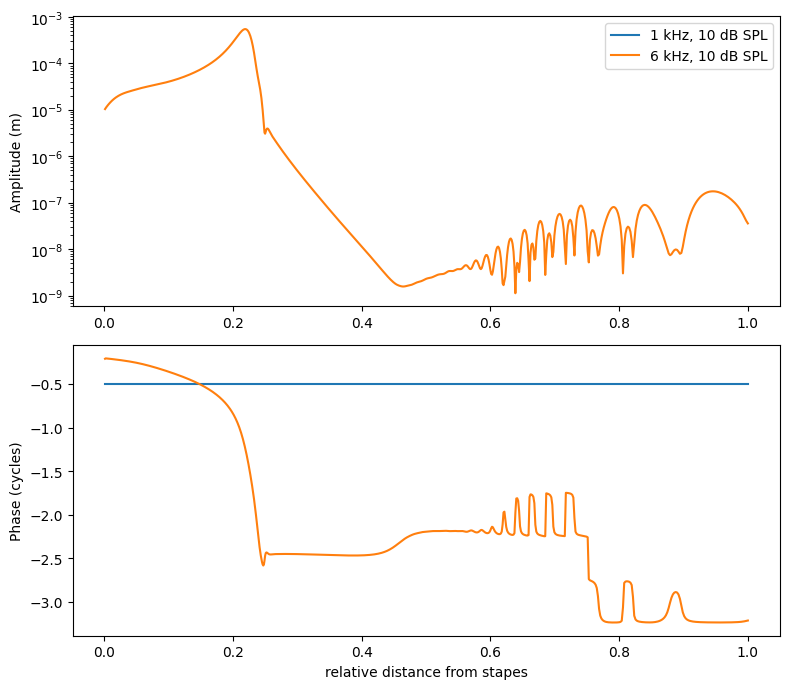

In [3]:
# ===== run_nobili.m: Nobili model in the time domain (two conditions, side-by-side animation) =====
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# --- conditions to simulate (F = tone frequency in Hz, L = level in dB SPL); any number >= 1
#   two levels:       [dict(F=1e3, L=10), dict(F=1e3, L=80)]
#   two frequencies:  [dict(F=1e3, L=10), dict(F=3e3, L=10)]
conditions = [dict(F=1e3, L=10), dict(F=6e3, L=10)]

# --- common parameters
Tdur = 0.02       # tone duration in seconds
phi1o = 0        # tone phase in radians
gain = 0.9       # 0 = passive model; larger gain -> sharper tuning (unstable if too high, 0.85 in the original work)
Ma = None        # y-limit of the BM displacement in the animation: None = automatic per condition,
                 # or a number / list of numbers (one per condition)
snap_every = 50  # BM snapshot every 50 steps (= 0.25 ms) for the animation; 0 = no animation
                 # (smaller value = smoother but heavier output)

# --- simulation (about 1 min per condition)
results = []
for cnd in conditions:
    Y1FT, oae, tim, snaps = CochleaRGB_Nobili(cnd['L'], cnd['F'], Tdur, 1, gain, phi1o, snap_every=snap_every)
    results.append(dict(cnd, Y1FT=Y1FT, oae=oae, snaps=snaps,
                        label=f"{cnd['F'] / 1e3:g} kHz, {cnd['L']:g} dB SPL"))

# --- amplitude and phase of the simulated traveling waves
x = alldataRG(800, 0, gain)[0]           # relative distance from stapes (load bmdatarg.mat x)
amps = [np.abs(r['Y1FT']).max() for r in results]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), num=3, clear=True)
for r in results:
    ax1.plot(x, np.abs(r['Y1FT']), label=r['label'])
    ax2.plot(x, np.unwrap(np.angle(r['Y1FT'])) / (2 * np.pi))
if max(amps) / min(amps) > 20:
    ax1.set_yscale('log')                # conditions differ strongly in amplitude
ax1.set_ylabel('Amplitude (m)'); ax1.legend()
ax2.set_ylabel('Phase (cycles)'); ax2.set_xlabel('relative distance from stapes')
fig.tight_layout()
plt.show()

# --- side-by-side animation: input signal (top) and BM displacement (bottom) per condition
if snap_every:
    plt.rcParams['animation.embed_limit'] = 100          # MB, allow long animations
    nC = len(results)
    Mlim = np.broadcast_to(np.array(Ma if Ma is not None else np.nan, dtype=float), (nC,))
    nfr = min(len(r['snaps']['t']) for r in results)
    tsig = tim[::5]

    figA, axs = plt.subplots(2, nC, figsize=(9.6 * nC, 4.2), dpi=50, squeeze=False)

    dots, lines = [], []
    for c, r in enumerate(results):
        sig = np.array([Inp_sigSFOAE(r['F'], r['L'], t, phi1o) for t in tsig])
        aU, aB = axs[0, c], axs[1, c]
        aU.plot(tsig, sig, lw=0.6)
        d, = aU.plot([], [], 'ro'); dots.append(d)
        aU.set_xlim(0, tim[-1]); aU.set_title(r['label']); aU.set_xlabel('Time (s)')
        aU.set_ylabel('Stapes acceleration')
        ylim = Mlim[c] if np.isfinite(Mlim[c]) else 1.1 * np.abs(r['snaps']['y']).max()
        l, = aB.plot(x, r['snaps']['y'][0], 'r'); lines.append(l)
        aB.set_xlim(0, 1); aB.set_ylim(-ylim, ylim); aB.grid(True)
        aB.set_xlabel('Relative distance from stapes'); aB.set_ylabel('BM displacement')
    figA.tight_layout()

    def update(i):
        for r, d, l in zip(results, dots, lines):
            ti = r['snaps']['t'][i]
            d.set_data([ti], [Inp_sigSFOAE(r['F'], r['L'], ti, phi1o)])
            l.set_ydata(r['snaps']['y'][i])
        return (*dots, *lines)

    anim = FuncAnimation(figA, update, frames=nfr, interval=30, blit=True)
    plt.close(figA)
    display(HTML(anim.to_jshtml()))                       # interactive player in the notebook


# ===== Optional: nonlinear frequency-domain iso-intensity response =====
RUN_NONLINEAR = False    # harmonic-balance iterations (a few seconds to minutes)

if RUN_NONLINEAR:
    Fvect = np.logspace(np.log10(500), np.log10(4000), 12)
    ExcF, YT, NLs, idxCh = iso_intrespF(Fvect, L=60, Nharm=3, gain=0.9)
    plt.figure(); plt.semilogy(Fvect, ExcF, 'o-')
    plt.xlabel('Frequency [Hz]'); plt.ylabel('|BM displacement| at BF place'); plt.grid(True)
    plt.show()